In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (123175384059)>


In [5]:
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"


# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            1.8*UNIT.ton / UNIT.m3, #rho ton /m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis

soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
node_offset, elem_offset = SF.generate_block(0.0, 0.0, 15.0, 4.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_Soil_block")
node_offset, elem_offset = SF.generate_block(9.5, 4.5, 5.5, 1.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAEa_Soil_block")
node_offset, elem_offset = SF.generate_block(12.0, 6.5, 3.0, 1.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAEb_Soil_block")

InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [6]:
start_node_id = SF.get_next_node_id(start_from=None)
int_node_coor = [
[11.5000 , 6.5000],
[11.0000 , 6.5000],
[ 8.5000 , 5.0000],
[ 9.0000 , 5.0000],
[ 9.0000 , 4.5000],
[ 8.5000 , 4.5000],
[ 8.0000 , 4.5000],
[ 7.5000 , 4.5000],
[ 6.0000 , 4.5000],
[ 6.5000 , 4.5000],
[ 7.0000 , 4.5000],
[ 7.0000 , 5.0000],
[ 7.5000 , 5.0000],
[ 8.0000 , 5.0000],
[ 8.0000 , 5.5000],
[ 8.5000 , 5.5000],
[ 9.0000 , 5.5000],
[ 9.0000 , 6.0000],
[ 9.5000 , 6.5000],
[10.0000 , 6.5000],
[10.5000 , 6.5000],
[10.5000 , 7.0000],
[11.0000 , 7.0000],
[11.5000 , 7.0000],
[11.5000 , 7.5000],
[ 5.3769 , 4.2154],
[ 5.7538 , 4.4308],
[ 5.9692 , 4.5538],
[ 6.3462 , 4.7692],
[ 6.7231 , 4.9846],
[ 6.9385 , 5.1077],
[ 7.3154 , 5.3231],
[ 7.6923 , 5.5385],
[ 7.9077 , 5.6615],
[ 8.2495 , 5.8568],
[ 8.6615 , 6.0923],
[ 8.8769 , 6.2154],
[ 9.2538 , 6.4308],
[ 9.4692 , 6.5538],
[ 9.8677 , 6.7815],
[10.2231 , 6.9846],
[10.4385 , 7.1077],
[10.8350 , 7.3343],
[11.1923 , 7.5385],
[11.4077 , 7.6615],
[11.7846 , 7.8769],
]

interface_nodes = SF.add_nodes_from_coordinates(coord_list = int_node_coor, start_id = start_node_id, block_name = "interface_nodes")

In [7]:
start_elem_id = SF.get_next_elem_id(start_from=None)
bot_a_nodes = list(range(261, 280))
top_a_nodes = [364,365,366,363,362,361,360] + list(range(280, 292))
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = bot_a_nodes, edge2_nodes = top_a_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quada_strip")

In [8]:
start_elem_id = SF.get_next_elem_id(start_from=None)
bot_b_nodes = [367,368,369,358,359,292]
top_b_nodes = [366,363,362,361,360,280]
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = bot_b_nodes, edge2_nodes = top_b_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quadb_strip")

In [9]:
start_elem_id = SF.get_next_elem_id(start_from=None)
bot_c_nodes = [369,358,359,292]
top_c_nodes = [370,371,372,304]
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = bot_c_nodes, edge2_nodes = top_c_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quadc_strip")

In [10]:
start_elem_id = SF.get_next_elem_id(start_from=None)
bot_d_nodes = list(range(316, 328))
top_d_nodes = [374,375,376,357,356] + list(range(328, 335))
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = bot_d_nodes, edge2_nodes = top_d_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quadd_strip")

In [11]:
start_elem_id = SF.get_next_elem_id(start_from=None)
bot_d_nodes = [376,357,356,328]
top_d_nodes = [377,378,379,335]
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = bot_d_nodes, edge2_nodes = top_d_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quadd_strip")

In [12]:
start_elem_id = SF.get_next_elem_id(start_from=None)
print(start_elem_id)

332


In [13]:
ops.element("quadWithSensitivity", 332, 372, 304, 316, 373, soil_thickness, etype, soil_mat_tag)
ops.element("quadWithSensitivity", 333, 379, 335, 342, 380, soil_thickness, etype, soil_mat_tag)

In [14]:
start_elem_id = SF.get_next_elem_id(start_from=None)
bot_d_nodes = [260,261,364,365,366,367,368,369,370,371,372,373,316,374,375,376,377,378,379,380,342]
top_d_nodes = list(range(381, 402))
patch = SF.create_quad_strip_from_nodes(
edge1_nodes = bot_d_nodes, edge2_nodes = top_d_nodes, start_elem_id =start_elem_id, 
thickness = soil_thickness, etype = etype, mat_tag = soil_mat_tag, block_name="quadd_strip")

In [15]:
start_elem_id = SF.get_next_elem_id(start_from=None)
print(start_elem_id)

354


In [16]:
ops.element("quadWithSensitivity", 354, 259, 259, 260, 381, soil_thickness, etype, soil_mat_tag)
ops.element("quadWithSensitivity", 355, 401, 401, 342, 349, soil_thickness, etype, soil_mat_tag)

In [17]:
bot_fixY = SF.fix_nodes_by_range(start_id =2, end_id = 30, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
left_fixY = SF.fix_nodes_by_range(start_id =32, end_id = 249, step =31, fixity = fixXonly, block_name="fixed_left_nodes_bottom")
right_fixY = SF.fix_nodes_by_range(start_id =62, end_id = 279, step =31, fixity = fixXonly, block_name="fixed_right_nodes_bottom")

node_list = [291,303,315,327,334,341,348,355]
righta_fixY = SF.fix_nodes_by_list(node_ids = node_list, fixity = fixXonly, block_name="fixed_nodes")
ops.fix(1, *fixXY)
ops.fix(31, *fixXY)

In [18]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

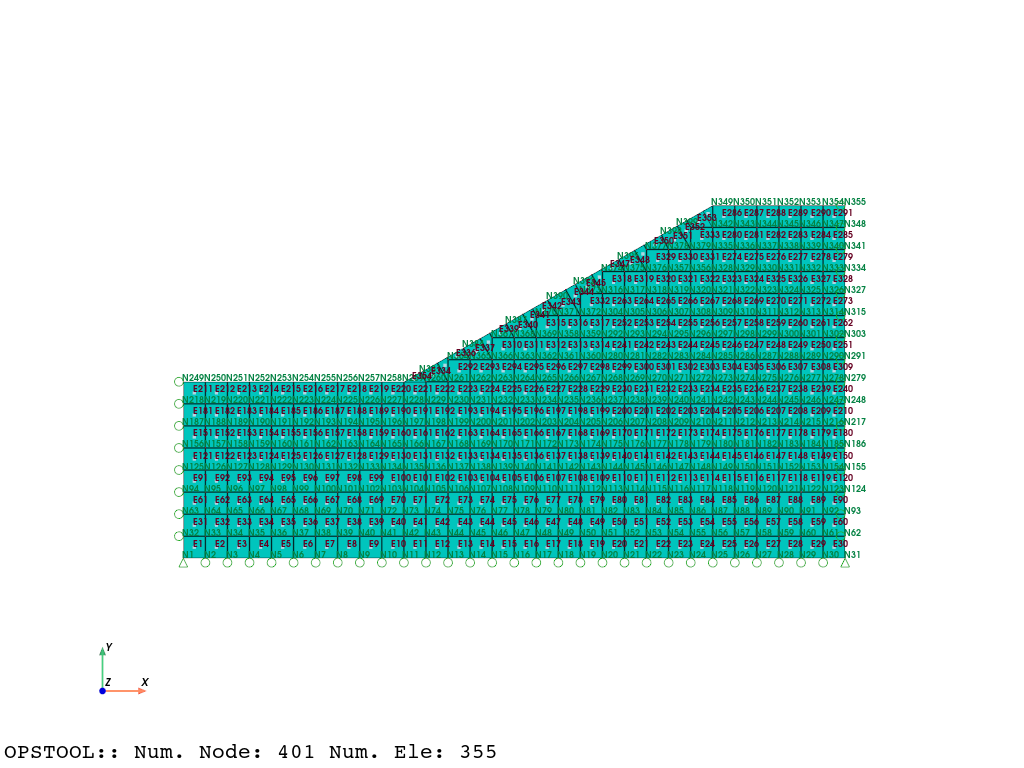

In [19]:
OPSVIS = opst.vis.pyvista
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [20]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [21]:
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [22]:
def analysis_steps(nsteps=4):
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [23]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

In [24]:
PN_1 = 50000*UNIT.N
print(PN_1)
ops.load(349, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

50.0


In [25]:
PN_1 = 50000*UNIT.N
print(PN_1)
ops.load(350, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

50.0


In [26]:
PN_1 = 50000*UNIT.N
print(PN_1)
ops.load(351, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

50.0


In [27]:
PN_1 = 50000*UNIT.N
print(PN_1)
ops.load(352, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

50.0


In [28]:
PN_1 = 50000*UNIT.N
print(PN_1)
ops.load(353, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

50.0


In [29]:
fig = opst.vis.plotly.plot_model(show_ele_loads=True, show_nodal_loads=True, load_scale=2)
fig.show()

In [30]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [31]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

In [32]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", title_font_size=12, notebook=True)


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

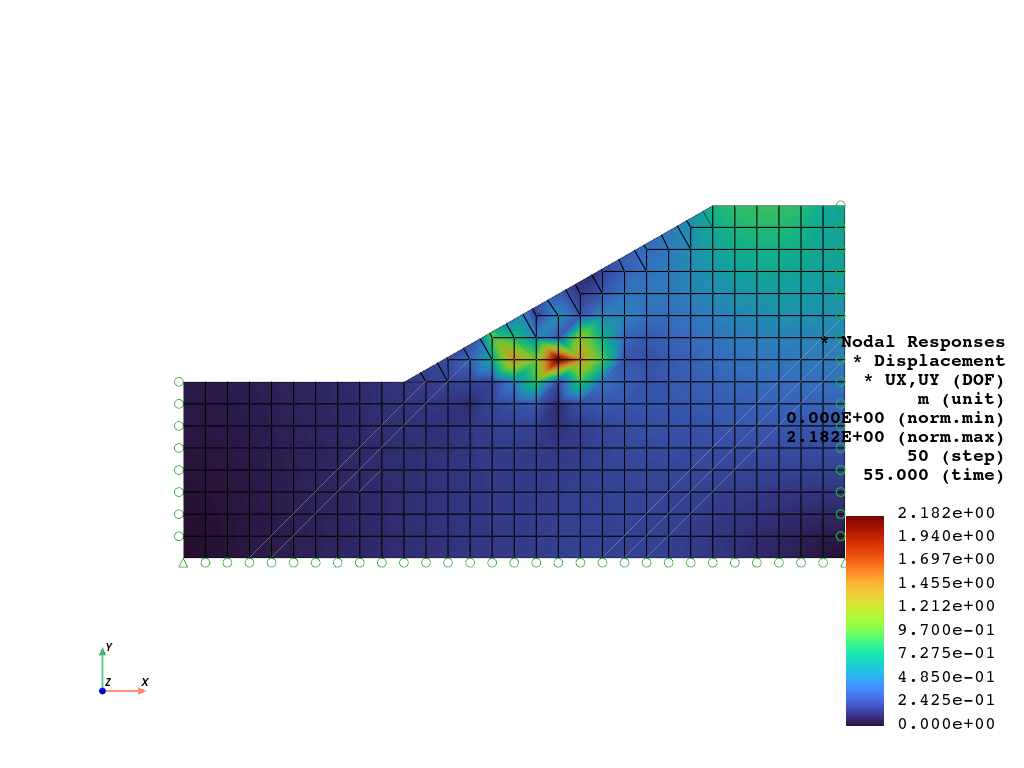

In [33]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=0.0001,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

In [34]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=1,
    scale=0.0001,
    savefig="slope.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to slope.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

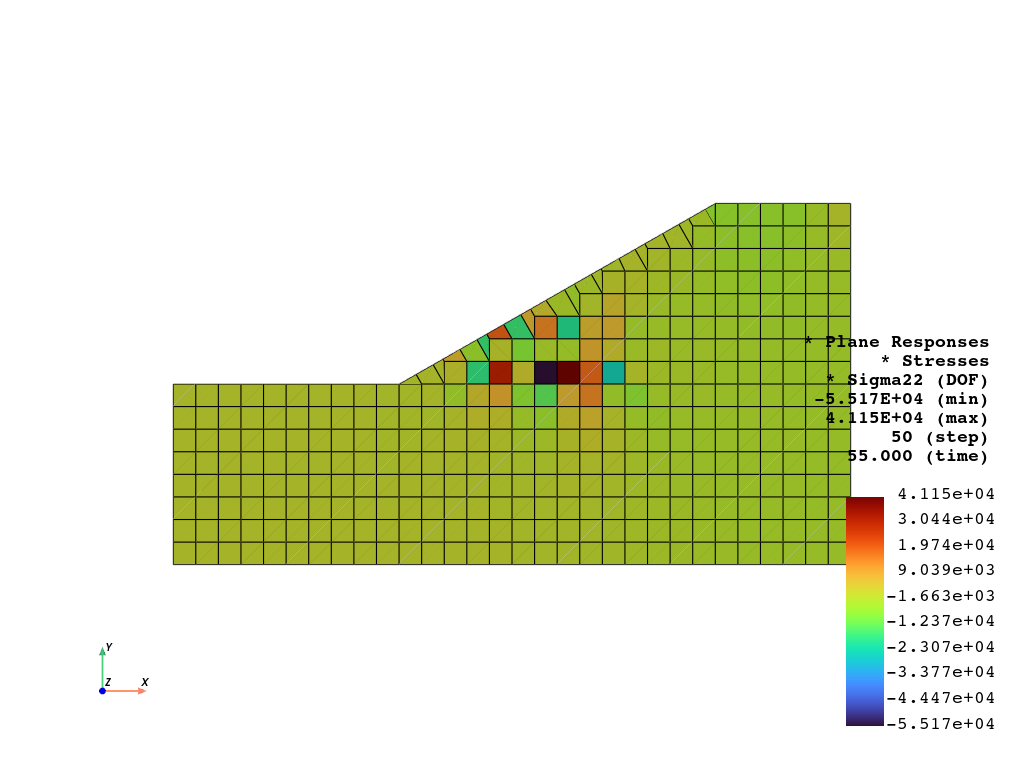

In [35]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22",bc_scale = 0.001,defo_scale = 0.001
).show(jupyter_backend="jupyterlab")